In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random
import warnings
import os
path_to_add = os.path.abspath('../')
sys.path.append(path_to_add)
from func_curvefit import *

In [2]:
root_folder = '../../data/subtlety_data/'

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

s=16 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=14) #fontsize of the x tick labels
plt.rc('ytick', labelsize=14) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

color_plots = 'tab:red' # or tab:red

In [4]:
# root_file = '/Users/f0053cz/Documents/psyanim_v2/subtlety/subtlety_v2_data_Zishan/data/'
batch_name1 = 'all_apr_ses1'
batch_name2 = 'all_apr_ses2'
curvefit_name1 = 'curve_fit_subt_ses1/all_params_1k_subt' #'curve_trait_apr_ses1'
curvefit_name2 = 'curve_fit_subt_ses2/all_params_1k_subt' #'curve_trait_apr_ses2'

In [5]:
# session 1 rating
df_group_test = pd.read_csv(f'{root_folder}{batch_name1}.csv')
df_group_test = df_group_test[df_group_test['condition'] != 'mimic']
df_group_test = df_group_test.loc[:, df_group_test.columns != 'stim_file']
df_group_test = df_group_test.groupby(['subID','condition','subtlety']).agg(['mean', 'std']).reset_index()
df_group_test = df_group_test.drop(['condition'], axis=1)
# session 1 curvefit
df_curve_test = pd.read_csv(f'{root_folder}{curvefit_name1}.csv')

# session 2 rating
df_group_retest = pd.read_csv(f'{root_folder}{batch_name2}.csv')
df_group_retest = df_group_retest[df_group_retest['condition'] != 'mimic']
df_group_retest = df_group_retest.loc[:, df_group_retest.columns != 'stim_file']
df_group_retest = df_group_retest.groupby(['subID','condition','subtlety']).agg(['mean', 'std']).reset_index()
df_group_retest = df_group_retest.drop(['condition'], axis=1)
# session 2 curvefit
df_curve_retest = pd.read_csv(f'{root_folder}{curvefit_name2}.csv')

# selecting participants (hand picked)
subID_select = [9, 19, 20, 304, 152, 186, 198]
df_rating_test_select = df_group_test[df_group_test['subID'].isin(subID_select)]
df_curve_test_select = df_curve_test[df_curve_test['subID'].isin(subID_select)]
df_rating_retest_select = df_group_retest[df_group_retest['subID'].isin(subID_select)]
df_curve_retest_select = df_curve_retest[df_curve_retest['subID'].isin(subID_select)]

/Users/f0053cz/anaconda3/envs/py37/lib/python3.7/site-packages/pandas/core/generic.py:4150: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  obj = obj._drop_axis(labels, axis, level=level, errors=errors)


In [6]:
df_group_test.shape, df_group_retest.shape

((2184, 10), (1680, 10))

In [7]:
intersecting_subs = df_group_retest[df_group_retest['subID'].isin(df_group_test['subID'])]
intersecting_subs = np.unique(intersecting_subs['subID'])
intersecting_subs

array([  2,   4,   5,   6,   7,   9,  10,  12,  13,  14,  15,  16,  18,
        19,  20,  21,  22,  25,  26,  27,  28,  29,  31,  33,  34,  35,
        37,  39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  50,  55,
        60,  61,  62,  63,  65,  66,  69,  70,  71,  73,  74,  75,  78,
        81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  92,  93,  94,
        96,  98, 101, 102, 104, 105, 106, 107, 108, 111, 112, 113, 114,
       115, 117, 118, 121, 122, 123, 125, 127, 128, 129, 130, 133, 134,
       135, 137, 138, 143, 144, 145, 146, 148, 149, 150, 151, 152, 154,
       158, 159, 160, 161, 162, 163, 165, 166, 167, 170, 171, 172, 173,
       175, 176, 177, 178, 179, 180, 181, 182, 183, 185, 186, 189, 191,
       192, 193, 194, 195, 197, 198, 199, 201, 202, 203, 205, 206, 208,
       209, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222,
       223, 224, 225, 226, 227, 228, 229, 230, 231, 233, 234, 235, 237,
       239, 240, 241, 242, 243, 244, 246, 248, 250, 252, 253, 25

In [8]:
df_group_test.shape, df_group_retest.shape, len(intersecting_subs)

((2184, 10), (1680, 10), 240)

In [9]:
# Remove these numbers from their current positions
intersecting_subs = [x for x in intersecting_subs if x not in subID_select]

# Insert them at the top
intersecting_subs = subID_select + intersecting_subs
intersecting_subs

[9,
 19,
 20,
 304,
 152,
 186,
 198,
 2,
 4,
 5,
 6,
 7,
 10,
 12,
 13,
 14,
 15,
 16,
 18,
 21,
 22,
 25,
 26,
 27,
 28,
 29,
 31,
 33,
 34,
 35,
 37,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 50,
 55,
 60,
 61,
 62,
 63,
 65,
 66,
 69,
 70,
 71,
 73,
 74,
 75,
 78,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 92,
 93,
 94,
 96,
 98,
 101,
 102,
 104,
 105,
 106,
 107,
 108,
 111,
 112,
 113,
 114,
 115,
 117,
 118,
 121,
 122,
 123,
 125,
 127,
 128,
 129,
 130,
 133,
 134,
 135,
 137,
 138,
 143,
 144,
 145,
 146,
 148,
 149,
 150,
 151,
 154,
 158,
 159,
 160,
 161,
 162,
 163,
 165,
 166,
 167,
 170,
 171,
 172,
 173,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 185,
 189,
 191,
 192,
 193,
 194,
 195,
 197,
 199,
 201,
 202,
 203,
 205,
 206,
 208,
 209,
 211,
 212,
 213,
 214,
 215,
 216,
 217,
 218,
 219,
 220,
 221,
 222,
 223,
 224,
 225,
 226,
 227,
 228,
 229,
 230,
 231,
 233,
 234,
 235,
 237,
 239,
 240,
 241,
 242,
 243,
 244,
 246,
 248,
 250,

### plotting

In [13]:
sub_title = [101, 102, 103, 104, 105, 106, 107] #[1001, 1002, 1003, 1004, 1005, 1006, 1007]

In [14]:
subID_select

[9, 19, 20, 304, 152, 186, 198]

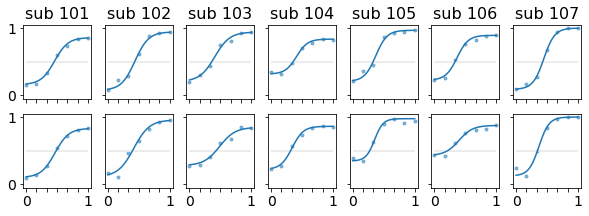

In [15]:
nrow, ncol = 2, 7
plt.subplots(nrows=nrow, ncols=ncol, figsize=(10, 3), sharey = True)

for session in range(nrow):
    for i in range(len(subID_select)):
        ax = plt.subplot(nrow, ncol, session * ncol + i + 1)
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)

        # try:
        if session == 0:
            df_rate = df_rating_test_select
            df_curve = df_curve_test_select
            
        else:
            df_rate = df_rating_retest_select
            df_curve = df_curve_retest_select
            
        xfit = (180 - df_rate.loc[df_rate['subID'] == subID_select[i], 'subtlety'].values) / 180
        yfit = df_rate.loc[df_rate['subID'] == subID_select[i], 'slider']['mean'].values / 100
        yerr = df_rate.loc[df_rate['subID'] == subID_select[i], 'slider']['std'].values / 100
        
        
        intercept = df_curve.loc[df_curve['subID'] == subID_select[i], 'bias_lower'].values
        center = df_curve.loc[df_curve['subID'] == subID_select[i], 'center'].values
        sigma = df_curve.loc[df_curve['subID'] == subID_select[i], 'sigma'].values
        bias_upper = df_curve.loc[df_curve['subID'] == subID_select[i], 'bias_upper'].values
        amplitude = 1 - intercept - bias_upper  
            
        x = np.array(xfit)
        y = np.array(yfit)
        
        # Plot behavioral dots
        ax.plot(x, y, '.', color='tab:blue', alpha=0.5)
#             ax.errorbar(x, y, yerr=yerr, fmt='.', color='gray', alpha=0.5)
        
        x_values = np.linspace(np.nanmin(x), np.nanmax(x), 100)
        y_values = intercept + amplitude * sigmoid(x_values, sigma, center)

        ax.hlines(0.5,0,1,color = [.9,.9,.9]) 
        
        # Plot the curves
        ax.plot(x_values, y_values, '-', color='tab:blue')
        ax.set_xticks(np.linspace(0,1,7))
        ax.set_xticklabels([0, '','','','','',  1])
        ax.set_yticks([0, 1])
        ax.set_yticklabels([0,   1])
        
        if session == 0:
            ax.set_title(f'sub {sub_title[i]}', size = 'medium')
            ax.tick_params(labelbottom=False)
            
plt.subplots_adjust(wspace=0.2, hspace=0.2)
plt.savefig('../../results/subtlety/sample_subs_single_sub_plot_nomimic.png',dpi=300,bbox_inches='tight')
# plt.show()

# all subs

In [13]:
# ses = 1 only

In [14]:
session = 0

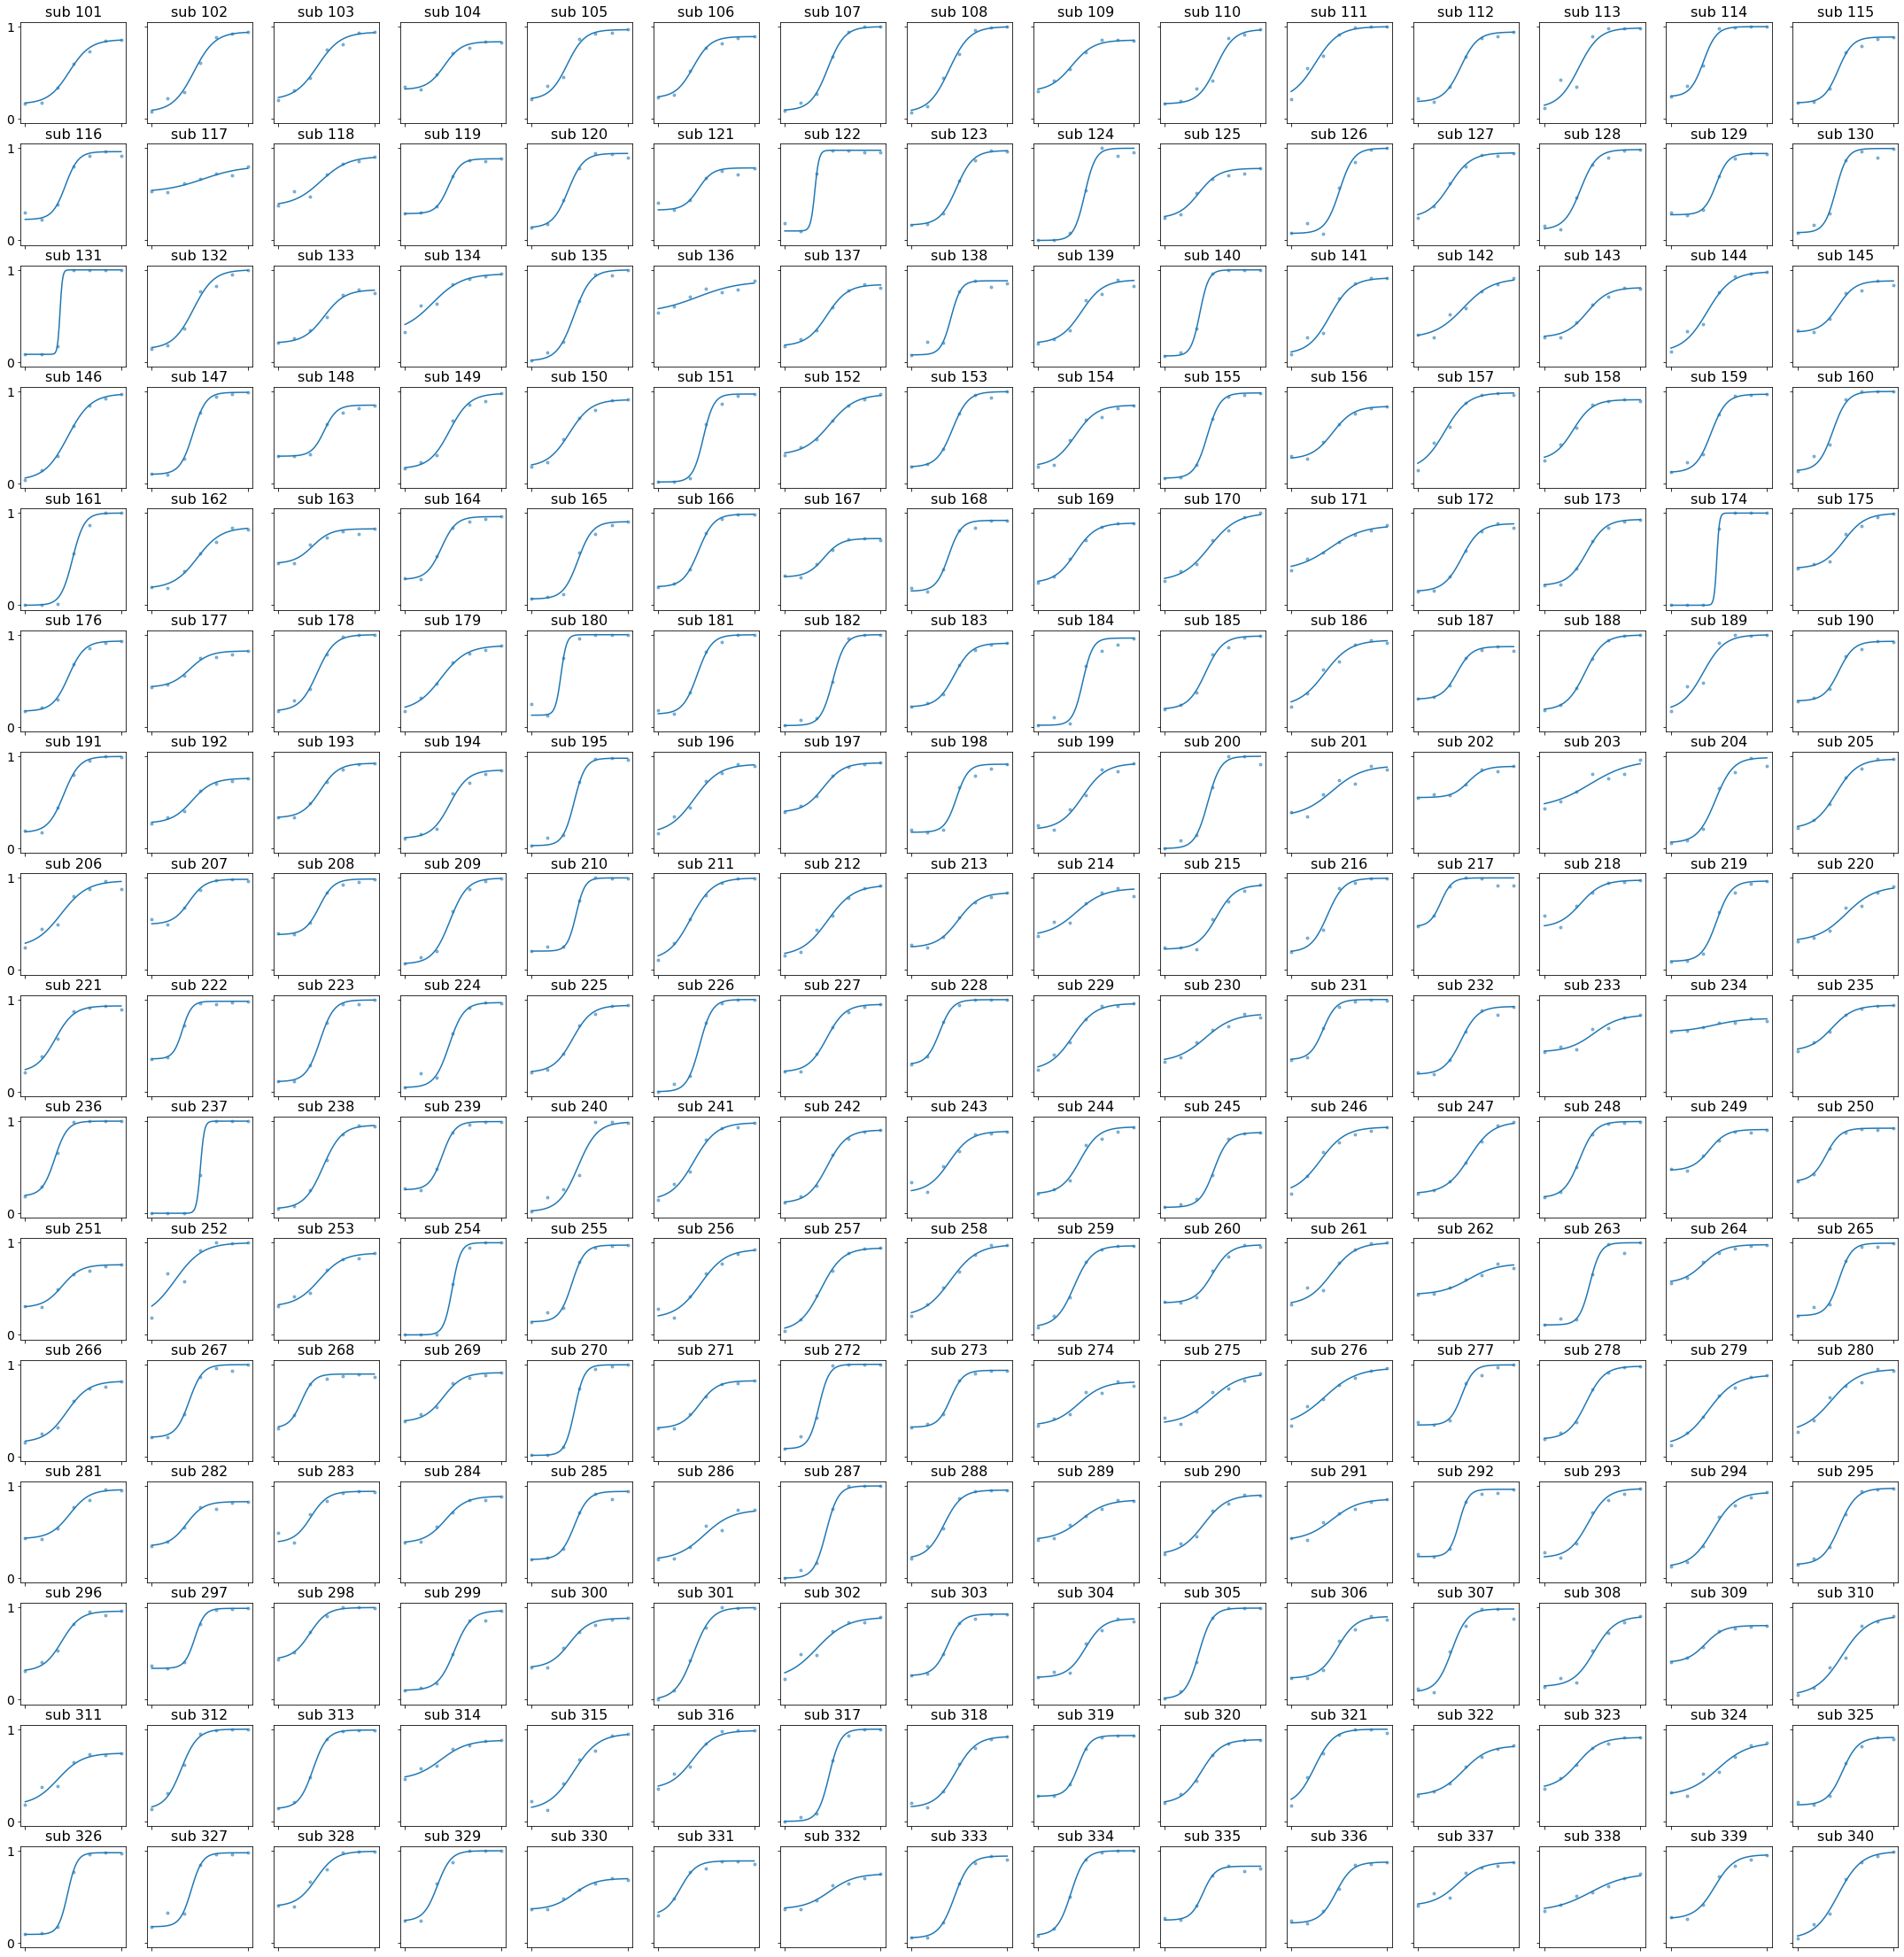

In [15]:
nrow, ncol = 16,15
fig,axs = plt.subplots(nrows=nrow, ncols=ncol, figsize=(38, 40), sharey = True)

for i in range(len(intersecting_subs)):
    row = int(np.floor(i/ncol))
    col = i%ncol
    ax = axs[row,col]

    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)

    # try:
    if session == 0:
        df_rate = df_group_test
        df_curve = df_curve_test
        
    else:
        df_rate = df_group_test
        df_curve = df_curve_retest
        
    xfit = (180 - df_rate.loc[df_rate['subID'] == intersecting_subs[i], 'subtlety'].values) / 180
    yfit = df_rate.loc[df_rate['subID'] == intersecting_subs[i], 'slider']['mean'].values / 100
    yerr = df_rate.loc[df_rate['subID'] == intersecting_subs[i], 'slider']['std'].values / 100
    
    
    intercept = df_curve.loc[df_curve['subID'] == intersecting_subs[i], 'bias_lower'].values
    center = df_curve.loc[df_curve['subID'] == intersecting_subs[i], 'center'].values
    sigma = df_curve.loc[df_curve['subID'] == intersecting_subs[i], 'sigma'].values
    bias_upper = df_curve.loc[df_curve['subID'] == intersecting_subs[i], 'bias_upper'].values
    amplitude = 1 - intercept - bias_upper  
        
    x = np.array(xfit)
    y = np.array(yfit)
    
    # Plot behavioral dots
    ax.plot(x, y, '.', color='tab:blue', alpha=0.5)
#             ax.errorbar(x, y, yerr=yerr, fmt='.', color='gray', alpha=0.5)
    
    x_values = np.linspace(np.nanmin(x), np.nanmax(x), 100)
    y_values = intercept + amplitude * sigmoid(x_values, sigma, center)

    # Plot the curves
    ax.plot(x_values, y_values, '-', color='tab:blue')
    ax.set_xticks([0, 1])
    # ax.set_xticklabels([180, 0])
    ax.set_yticks([0, 1])
    ax.set_yticklabels([0, 1])
    if session == 0:
        ax.set_title(f'sub {101+i}', size = 'medium')
        ax.tick_params(labelbottom=False)

plt.subplots_adjust(wspace=0.2, hspace=0.2)
plt.savefig('../../results/subtlety/all_subs_single_sub_plot_nomimic_ses1.png',dpi=300,bbox_inches='tight')

In [16]:
session=1

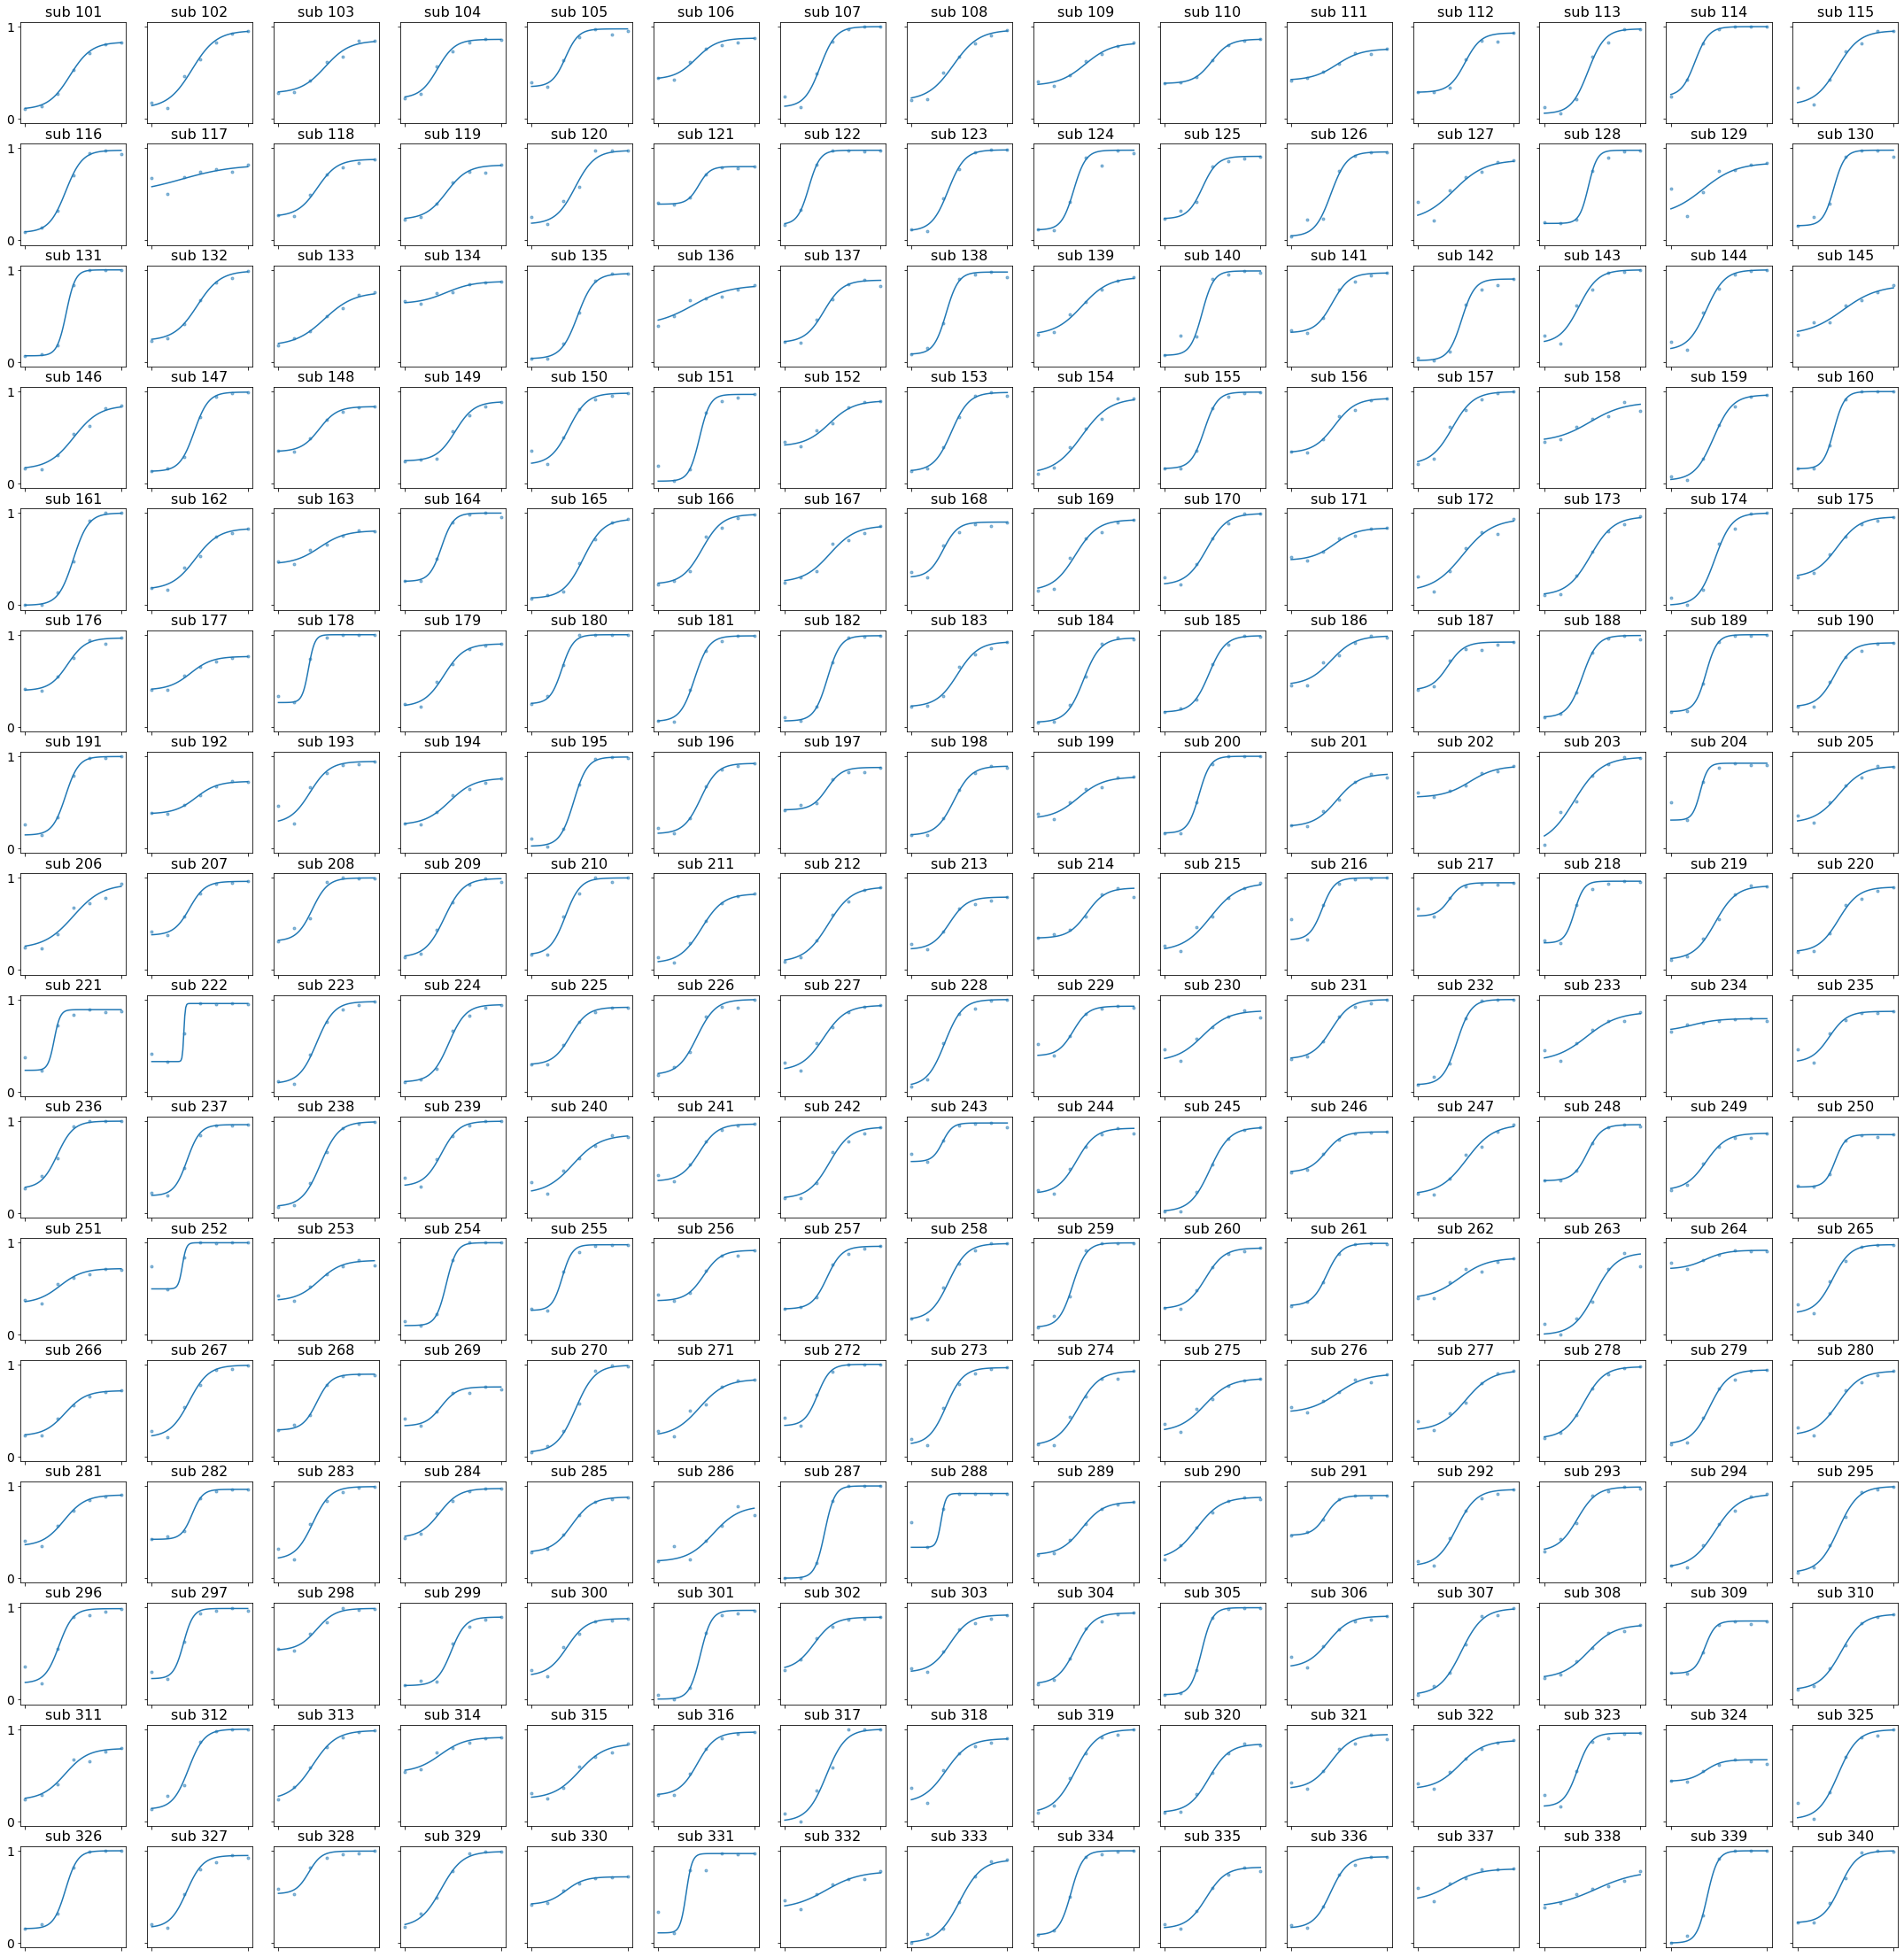

In [17]:
nrow, ncol = 16,15
fig,axs = plt.subplots(nrows=nrow, ncols=ncol, figsize=(38, 40), sharey = True)

for i in range(len(intersecting_subs)):
    row = int(np.floor(i/ncol))
    col = i%ncol
    ax = axs[row,col]

    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)

    if session == 0:
        df_rate = df_group_test
        df_curve = df_curve_test
        
    else:
        df_rate = df_group_retest
        df_curve = df_curve_retest
        
    xfit = (180 - df_rate.loc[df_rate['subID'] == intersecting_subs[i], 'subtlety'].values) / 180
    yfit = df_rate.loc[df_rate['subID'] == intersecting_subs[i], 'slider']['mean'].values / 100
    yerr = df_rate.loc[df_rate['subID'] == intersecting_subs[i], 'slider']['std'].values / 100
    
    
    intercept = df_curve.loc[df_curve['subID'] == intersecting_subs[i], 'bias_lower'].values
    center = df_curve.loc[df_curve['subID'] == intersecting_subs[i], 'center'].values
    sigma = df_curve.loc[df_curve['subID'] == intersecting_subs[i], 'sigma'].values
    bias_upper = df_curve.loc[df_curve['subID'] == intersecting_subs[i], 'bias_upper'].values
    amplitude = 1 - intercept - bias_upper  
        
    x = np.array(xfit)
    y = np.array(yfit)
    
    # Plot behavioral dots
    ax.plot(x, y, '.', color='tab:blue', alpha=0.5)    
    x_values = np.linspace(np.nanmin(x), np.nanmax(x), 100)
    y_values = intercept + amplitude * sigmoid(x_values, sigma, center)

    # Plot the curves
    ax.plot(x_values, y_values, '-', color='tab:blue')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_yticklabels([0, 1])
    if session == 1:
        ax.set_title(f'sub {101+i}', size = 'medium')
        ax.tick_params(labelbottom=False)
 
plt.subplots_adjust(wspace=0.2, hspace=0.2)
plt.savefig('../../results/subtlety/all_subs_single_sub_plot_nomimic_ses2.png',dpi=300,bbox_inches='tight')